# 13 — Partial-order analysis of group access

The weighted score in notebook 09 collapses every group onto a single
line: *more privileged* on the right, *more restricted* on the left.
That hides cases where two groups each have access to resources the
other lacks. They are not above or below each other — they are
**incomparable**, and that incomparability is itself a fact about the
society.

This notebook treats each group as a profile across the 8 resource
types and asks, pair by pair, whether one profile *dominates* another.

**Dominance rule.** For a group $g$ and resource type $r$, let

$$ \mathrm{sign}(g,r) = \begin{cases}
  +1 & \text{net MORE − LESS} > 0 \\
  -1 & \text{net MORE − LESS} < 0 \\
  \phantom{+}0 & \text{otherwise (no rules, or balanced)}
\end{cases} $$

with $-1 < 0 < +1$. Group $A$ dominates $B$ ($A \succeq B$) iff
$\mathrm{sign}(A,r) \ge \mathrm{sign}(B,r)$ for every $r$.

If $A \succeq B$ and $B \succeq A$ they have identical profiles. If
neither holds they are **incomparable** — one cannot be ranked above
the other without choosing which dimensions matter.

**What this gives that a one-dimensional score cannot:**
1. A **Hasse diagram** per period showing the actual dominance
   structure between groups.
2. **Width** — the largest set of mutually incomparable groups.
   A wider order means a society with multiple status axes that don't
   reduce to one ladder.
3. **Height** — the longest chain of strict dominance.
4. **Cover-edge churn** between periods — which dominance relations
   appeared, disappeared, or were preserved as the corpus moves from
   Classical Athens into the Roman Empire.
5. **Why two groups are incomparable** — listed dimension by dimension.

*Source: `data/clean/final/rules_final_dataset_130works_april_2026.tsv`.
Follows `notebook_rule.md`.*

## 1. Setup

In [1]:
import random
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

DATA = Path('../data/clean/final/rules_final_dataset_130works_april_2026.tsv')

# Resource type axes — order matches notebook 09 (materiality rank).
RESOURCE_TYPES = [
    'Bodily Autonomy', 'Legal Standing', 'Household Authority',
    'Material Wealth', 'Education', 'Political Power',
    'Honor', 'Religious Standing',
]

# Six canonical groups from the binary criteria in notebook 09. Adding
# Foreigners and Minors because they are well-attested and structurally
# distinct from the six.
GROUPS = ['Citizens', 'Slaves', 'The wealthy', 'The poor',
          'Men', 'Women', 'Foreigners', 'Minors']

# A group must have at least this many rules in a slice to be plotted.
MIN_RULES = 5

# Period order, oldest → newest.
PERIODS = [
    'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)',
    'Hellenistic & Early Roman (165 BCE – 105 CE)',
    'High Roman Empire (135–205 CE)',
]

In [2]:
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.bottom': False,
    'axes.spines.left': False,
    'axes.linewidth': 0.6,
    'xtick.major.size': 0,
    'ytick.major.size': 0,
    'xtick.labelbottom': False,
    'ytick.labelleft': False,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.frameon': False,
})

POS_COLOR  = '#2c6e91'   # +1 cell
NEG_COLOR  = '#c0392b'   # -1 cell
ZERO_COLOR = '#ecedef'   # 0 cell
EDGE_COLOR = '#1d1d1f'
NODE_FACE  = '#ffffff'
NODE_EDGE  = '#1d1d1f'

## 2. Load and preprocess

In [3]:
df_raw = pd.read_csv(DATA, sep='\t')
print(f'Loaded {len(df_raw):,} rules from {DATA.name}')

n0 = len(df_raw)
df = df_raw[df_raw['directionality'].isin(['MORE', 'LESS'])
            & df_raw['group_meta'].notna()
            & df_raw['resource_type'].notna()].copy()
df['resource_type_primary'] = (df['resource_type']
                               .map(lambda s: s.split(';')[0].strip()))

# Multi-label group_meta: explode on ';'.
df = (df.assign(group_meta=df['group_meta'].str.split(r'\s*;\s*'))
        .explode('group_meta'))
df['group_meta'] = df['group_meta'].str.strip()
df = df[df['group_meta'] != ''].copy()
n_with_period = df['period'].notna().sum()
n_no_period = df['period'].isna().sum()
df = df[df['period'].notna()].copy()

print(f'After MORE/LESS + group + resource_type filter, '
      f'group_meta exploded: {n_with_period + n_no_period:,} rule-rows from {n0:,}')
print(f'Dropped {n_no_period:,} rule-rows with missing period; '
      f'{len(df):,} kept.')

unknown_periods = set(df['period']) - set(PERIODS)
assert not unknown_periods, f'Unexpected period values: {unknown_periods}'
df.head()

Loaded 1,011 rules from rules_final_dataset_130works_april_2026.tsv
After MORE/LESS + group + resource_type filter, group_meta exploded: 1,124 rule-rows from 1,011
Dropped 97 rule-rows with missing period; 1,027 kept.


,rule_uid,file_id,perseus_author,perseus_title,wikidata_work_id,wikidata_work_label,author_wikidata_id,author_impact_date,year,period,...,immutability_reasoning,rule_contemporarity,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning,resource_type,group_meta,resource_type_primary
0,tlg0007.tlg118.perseus-eng3::0,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Greek ethnicity is a birth-fixed biological/cu...,0,Plutarch describes the current Roman administr...,5,Verbatim states the limitation as a plain hist...,0,Ethnicity does not inherently define level of ...,Political Power,Greeks,Political Power
1,tlg0007.tlg118.perseus-eng3::1,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Citizenship in a Greek city-state is a rigid l...,0,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...,Political Power,Citizens,Political Power
1,tlg0007.tlg118.perseus-eng3::1,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Citizenship in a Greek city-state is a rigid l...,0,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...,Political Power,Greeks,Political Power
2,tlg0007.tlg118.perseus-eng3::2,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,'Noble birth' is a strictly immutable lineage-...,0,Plutarch addresses a living recipient about hi...,4,"Frames eligibility as a matter of birthright, ...",0,Nobility does not always formally mandate poli...,Political Power,Nobles,Political Power
3,tlg0007.tlg118.perseus-eng3::3,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Status as 'Athenian citizens' and 'free men' i...,0,Refers to the current population of Athens rul...,4,"While hortatory, it identifies the group as 'f...",0,Being 'free' or 'Greek' does not automatically...,Political Power,Citizens,Political Power


## 3. Partial-order utilities

Three building blocks: **(a)** build a sign vector per group from a
slice of `df`, **(b)** test pairwise dominance, **(c)** compute the
Hasse cover relation, height, width, and the list of antichains.

In [4]:
def build_profiles(slice_df: pd.DataFrame,
                   groups: list[str] = GROUPS,
                   resources: list[str] = RESOURCE_TYPES,
                   min_rules: int = MIN_RULES,
                   ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return (net_matrix, sign_matrix, group_counts) for the given slice.

    Only groups with ≥ min_rules rule-rows are kept.
    """
    sub = slice_df[slice_df['group_meta'].isin(groups)]
    counts = sub['group_meta'].value_counts()
    keep = [g for g in groups if counts.get(g, 0) >= min_rules]

    more = (sub[sub['directionality'] == 'MORE']
            .groupby(['group_meta', 'resource_type_primary']).size()
            .unstack(fill_value=0)
            .reindex(index=keep, columns=resources, fill_value=0))
    less = (sub[sub['directionality'] == 'LESS']
            .groupby(['group_meta', 'resource_type_primary']).size()
            .unstack(fill_value=0)
            .reindex(index=keep, columns=resources, fill_value=0))
    net = (more - less).astype(int)
    sign = np.sign(net).astype(int)
    group_counts = counts.reindex(keep).astype(int).rename('n_rules')
    return net, sign, group_counts


def dominates(a: np.ndarray, b: np.ndarray) -> bool:
    """True iff a ≥ b component-wise (a dominates b weakly)."""
    return bool(np.all(a >= b))


def strict_dominates(a: np.ndarray, b: np.ndarray) -> bool:
    return dominates(a, b) and bool(np.any(a > b))


def hasse_cover(sign: pd.DataFrame) -> nx.DiGraph:
    """Cover relation of the partial order on groups in `sign`.

    An edge A → B means A *strictly covers* B: A > B and there is no
    intermediate C with A > C > B. Edges between groups with identical
    profiles are skipped (they are merged into one node label).
    """
    groups = list(sign.index)
    arrs = {g: sign.loc[g].values for g in groups}

    # Equivalence classes by identical profile.
    cls: dict[tuple, list[str]] = defaultdict(list)
    for g in groups:
        cls[tuple(arrs[g])].append(g)
    reps = {key: ' / '.join(members) for key, members in cls.items()}

    G = nx.DiGraph()
    for key, label in reps.items():
        G.add_node(label, profile=np.array(key))

    keys = list(reps)
    # First all strict-dominance edges, then transitive reduction.
    for k1 in keys:
        for k2 in keys:
            if k1 == k2:
                continue
            if strict_dominates(np.array(k1), np.array(k2)):
                G.add_edge(reps[k1], reps[k2])

    G_cover = nx.transitive_reduction(G) if G.edges else G
    # Carry node attributes through (transitive_reduction drops them).
    for n, data in G.nodes(data=True):
        if n in G_cover:
            G_cover.nodes[n].update(data)
    return G_cover


def order_height(G: nx.DiGraph) -> int:
    """Longest chain length (number of nodes, not edges)."""
    if not G.nodes:
        return 0
    return nx.dag_longest_path_length(G) + 1


def order_width(G: nx.DiGraph) -> int:
    """Width = size of the largest antichain. Computed via Dilworth's
    theorem: equal to the minimum chain cover, which equals
    `len(nodes) - max_matching` in the bipartite graph of the strict
    partial order."""
    if not G.nodes:
        return 0
    # Reachability closure encodes the strict partial order.
    closure = nx.transitive_closure_dag(G)
    nodes = list(closure.nodes)
    # Bipartite: left copy → right copy with an edge whenever
    # left ≻ right in the order.
    B = nx.Graph()
    for u in nodes:
        B.add_node(('L', u))
        B.add_node(('R', u))
    for u, v in closure.edges:
        B.add_edge(('L', u), ('R', v))
    matching = nx.bipartite.maximum_matching(
        B, top_nodes=[('L', u) for u in nodes])
    # Each pair (L,u)-(R,v) is counted twice in the dict; halve.
    matched_edges = len(matching) // 2
    return len(nodes) - matched_edges


def antichains(G: nx.DiGraph) -> list[list[str]]:
    """All maximal antichains, computed brute-force on the closure."""
    if not G.nodes:
        return []
    closure = nx.transitive_closure_dag(G)
    nodes = list(closure.nodes)
    related = {(u, v) for u, v in closure.edges}
    related |= {(v, u) for u, v in closure.edges}

    def is_antichain(s):
        return all((u, v) not in related for u, v in combinations(s, 2))

    out = []
    for r in range(1, len(nodes) + 1):
        for combo in combinations(nodes, r):
            if is_antichain(combo):
                out.append(list(combo))
    # Keep only maximal: drop any that is a subset of another.
    out.sort(key=len, reverse=True)
    maximal = []
    for s in out:
        if not any(set(s) < set(m) for m in maximal):
            maximal.append(s)
    return maximal


def incomparable_pairs(sign: pd.DataFrame) -> pd.DataFrame:
    """For every pair of groups that are incomparable, list the
    resource types where each one outranks the other."""
    rows = []
    groups = list(sign.index)
    for a, b in combinations(groups, 2):
        va, vb = sign.loc[a].values, sign.loc[b].values
        if dominates(va, vb) or dominates(vb, va):
            continue
        a_higher = [r for r, x, y in zip(sign.columns, va, vb) if x > y]
        b_higher = [r for r, x, y in zip(sign.columns, va, vb) if y > x]
        rows.append({
            'group_A': a,
            'group_B': b,
            f'A_outranks_B_on': '; '.join(a_higher),
            f'B_outranks_A_on': '; '.join(b_higher),
        })
    return pd.DataFrame(rows)

### 3a. Smoke test on the whole corpus

Single Hasse diagram across all 1,000+ rule-rows. Sanity check: we
expect Citizens to dominate Slaves, and Men to sit above Women on
several axes.

In [5]:
net_all, sign_all, n_all = build_profiles(df)
print('Net (MORE − LESS) per group × resource type — full corpus:')
print(net_all.to_string())
print()
print('Sign profile:')
print(sign_all.to_string())
print()
print(f'Groups retained: {list(net_all.index)}')
print(f'Group counts:    {n_all.to_dict()}')

Net (MORE − LESS) per group × resource type — full corpus:
resource_type_primary  Bodily Autonomy  Legal Standing  Household Authority  Material Wealth  Education  Political Power  Honor  Religious Standing
group_meta                                                                                                                                         
Citizens                            13              38                    0               -6          4               67      4                  -2
Slaves                             -20               6                    0                1          0               -6      0                  -1
The wealthy                          4               0                    0              -46          1               14      0                   0
The poor                             0              -4                    0                4          1               -5     -1                   1
Men                                 -1               

In [6]:
G_all = hasse_cover(sign_all)
print(f'Cover edges (full corpus): {list(G_all.edges)}')
print(f'Height: {order_height(G_all)}    Width: {order_width(G_all)}')

Cover edges (full corpus): [('Citizens', 'Foreigners'), ('Men', 'Slaves'), ('Men', 'Women'), ('Minors', 'Foreigners')]
Height: 2    Width: 6


## 4. Hasse diagram drawing helper

We layout nodes on horizontal layers using the longest path *down* from
each node — so groups at the top dominate everyone below them, and
nodes on the same row are pairwise incomparable.

In [7]:
def hasse_layout(G: nx.DiGraph) -> dict[str, tuple[float, float]]:
    """Layered layout: y = longest-down-distance to a sink, x spread
    per layer. Top of the figure = top of the order (dominators).
    """
    if not G.nodes:
        return {}

    # rank = longest path length to a sink (so sinks have rank 0).
    rev = G.reverse(copy=True)
    rank = {}
    for n in nx.topological_sort(G):
        # length to a sink in original = length from n in reversed,
        # but easier: longest path FROM n in G.
        pass

    # compute longest path from each node in G (toward sinks) by DP
    # on a topological order of G.
    topo = list(nx.topological_sort(G))
    longest_from = {n: 0 for n in topo}
    for n in reversed(topo):
        for s in G.successors(n):
            longest_from[n] = max(longest_from[n], longest_from[s] + 1)
    # rank = longest_from[n] (sinks at 0, dominators higher)
    rank = longest_from

    # group nodes by rank, sort within rank for stable x order.
    layers = defaultdict(list)
    for n, r in rank.items():
        layers[r].append(n)
    pos = {}
    for r, nodes in layers.items():
        nodes.sort()
        n_at = len(nodes)
        # spread between x = -1 and x = 1
        if n_at == 1:
            xs = [0.0]
        else:
            xs = list(np.linspace(-1, 1, n_at))
        for n, x in zip(nodes, xs):
            pos[n] = (x, float(r))
    return pos


def draw_hasse(G: nx.DiGraph, ax, *, title: str = '',
               n_rules: pd.Series | None = None):
    pos = hasse_layout(G)

    # Edges first.
    for u, v in G.edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='-', lw=0.9,
                                    color=EDGE_COLOR,
                                    shrinkA=18, shrinkB=18))

    # Nodes.
    for n, (x, y) in pos.items():
        label = n
        if n_rules is not None:
            # label can be 'A / B' if profiles tied; pick smallest count
            # so we don't mislead about sample size.
            members = n.split(' / ')
            ns = [int(n_rules.get(m, 0)) for m in members]
            label = '\n'.join(members) + f'\n(n={min(ns)})'
        ax.scatter(x, y, s=2400, facecolor=NODE_FACE,
                   edgecolor=NODE_EDGE, linewidths=1.0, zorder=3)
        ax.text(x, y, label, ha='center', va='center', fontsize=8.5,
                zorder=4)

    if pos:
        xs = [p[0] for p in pos.values()]
        ys = [p[1] for p in pos.values()]
        ax.set_xlim(min(xs) - 0.5, max(xs) + 0.5)
        ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, loc='left', fontsize=11, fontweight='bold')

### Figure 1: Hasse diagram — full corpus

Sanity check, no period split. An arrow $A \to B$ reads "$A$ dominates
$B$ in the partial order" — $A$'s sign profile is component-wise ≥
$B$'s and strictly greater on at least one axis. Groups on the same
row with no path between them are mutually incomparable.

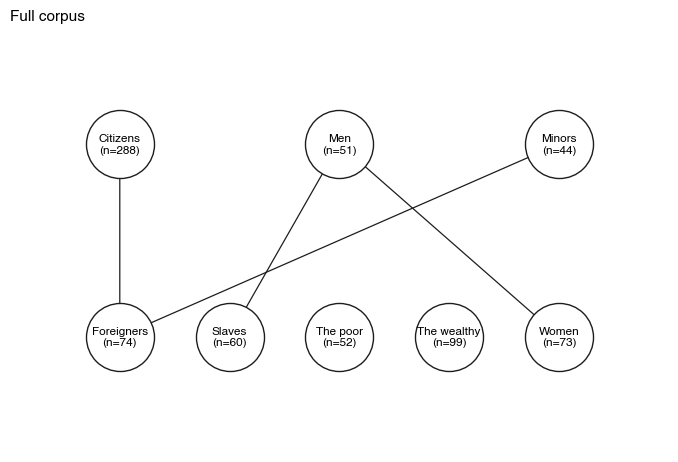

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
draw_hasse(G_all, ax, title='Full corpus', n_rules=n_all)
plt.show()

## 5. By period — Hasse diagrams

A group needs ≥ `MIN_RULES` rule-rows in the period to appear. The
sample shrinks fast at the edges of the corpus, so the High Roman
Empire diagram is much sparser than Late Classical.

In [9]:
period_data = {}
for p in PERIODS:
    sub = df[df['period'] == p]
    net_p, sign_p, n_p = build_profiles(sub)
    G_p = hasse_cover(sign_p)
    period_data[p] = dict(net=net_p, sign=sign_p, n=n_p, G=G_p,
                          slice=sub)
    print(f'{p}: {len(sub):,} rule-rows  '
          f'→ {len(sign_p)} groups kept '
          f'(width={order_width(G_p)}, height={order_height(G_p)})')

Classical (500–360 BCE): 323 rule-rows  → 7 groups kept (width=4, height=2)


Late Classical (354–165 BCE): 431 rule-rows  → 8 groups kept (width=6, height=3)
Hellenistic & Early Roman (165 BCE – 105 CE): 186 rule-rows  → 7 groups kept (width=6, height=2)
High Roman Empire (135–205 CE): 87 rule-rows  → 5 groups kept (width=3, height=2)


### Figure 2: Hasse diagrams across the four periods

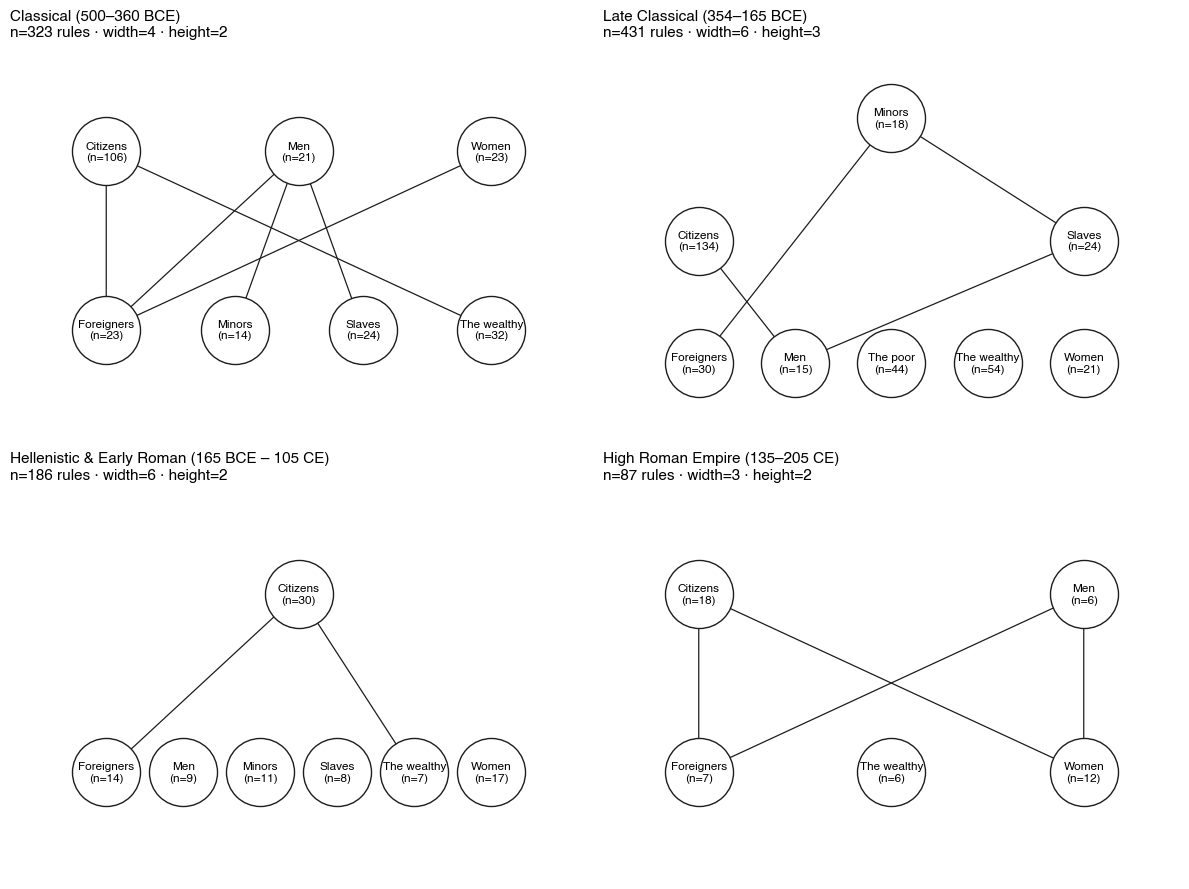

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, p in zip(axes.flat, PERIODS):
    d = period_data[p]
    title = (f'{p}\n'
             f'n={len(d["slice"]):,} rules · '
             f'width={order_width(d["G"])} · '
             f'height={order_height(d["G"])}')
    draw_hasse(d['G'], ax, title=title, n_rules=d['n'])
fig.tight_layout()
plt.show()

## 6. Width / height summary

- **Width** = size of the largest antichain (mutually incomparable
  groups). Higher = more dimensions of status that don't reduce to a
  single ladder.
- **Height** = longest chain of strict dominance.
- A society where everyone fits on a line has height = number of
  groups and width = 1.

In [11]:
summary_rows = []
for p in PERIODS:
    d = period_data[p]
    G = d['G']
    summary_rows.append({
        'period': p,
        'n_rules': len(d['slice']),
        'n_groups_in_order': G.number_of_nodes(),
        'cover_edges': G.number_of_edges(),
        'height': order_height(G),
        'width': order_width(G),
        'incomparable_pairs': len(incomparable_pairs(d['sign'])),
    })
summary_df = pd.DataFrame(summary_rows).set_index('period')
summary_df

,n_rules,n_groups_in_order,cover_edges,height,width,incomparable_pairs
period,,,,,,
Classical (500–360 BCE),323,7,6,2,4,15
Late Classical (354–165 BCE),431,8,4,3,6,23
Hellenistic & Early Roman (165 BCE – 105 CE),186,7,2,2,6,19
High Roman Empire (135–205 CE),87,5,4,2,3,6


### Figure 3: Width and height across periods

A line plot makes the trajectory legible. Width going up = the order
gets *flatter and wider*, more incomparability; height going up = the
order gets *taller*, more layered dominance.

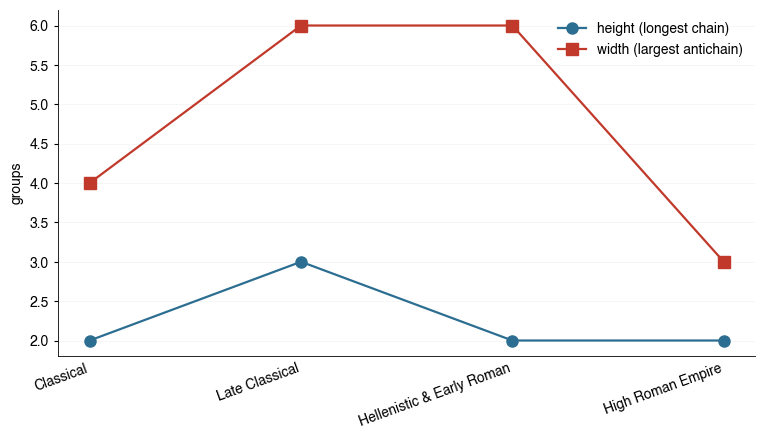

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(PERIODS))
ax.plot(x, summary_df['height'], '-o', color='#2c6e91', lw=1.6,
        markersize=8, label='height (longest chain)')
ax.plot(x, summary_df['width'], '-s', color='#c0392b', lw=1.6,
        markersize=8, label='width (largest antichain)')
ax.set_xticks(x)
ax.set_xticklabels([p.split(' (')[0] for p in PERIODS], rotation=20,
                   ha='right')
ax.tick_params(axis='x', labelbottom=True)
ax.tick_params(axis='y', labelleft=True, length=3)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.set_ylabel('groups')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.15, linewidth=0.5)
ax.set_axisbelow(True)
plt.show()

## 7. Period-to-period diff: cover-edge churn

Three categories per consecutive pair of periods:
- **gained**: cover edge present in the later period but not the earlier
- **lost**: cover edge present in the earlier period but not the later
- **kept**: same cover edge in both

Only edges between groups that appear in *both* periods are counted —
otherwise vanished/new groups would dominate the report.

In [13]:
def edge_diff(G1, G2):
    e1, e2 = set(G1.edges), set(G2.edges)
    common_nodes = set(G1.nodes) & set(G2.nodes)
    e1c = {(u, v) for u, v in e1 if u in common_nodes and v in common_nodes}
    e2c = {(u, v) for u, v in e2 if u in common_nodes and v in common_nodes}
    return dict(common_nodes=sorted(common_nodes),
                kept=sorted(e1c & e2c),
                lost=sorted(e1c - e2c),
                gained=sorted(e2c - e1c))


diff_rows = []
for p1, p2 in zip(PERIODS, PERIODS[1:]):
    d = edge_diff(period_data[p1]['G'], period_data[p2]['G'])
    diff_rows.append({
        'transition':   f'{p1.split(" (")[0]} → {p2.split(" (")[0]}',
        'common_groups': len(d['common_nodes']),
        'kept':          len(d['kept']),
        'lost':          len(d['lost']),
        'gained':        len(d['gained']),
        'kept_edges':    d['kept'],
        'lost_edges':    d['lost'],
        'gained_edges':  d['gained'],
    })

diff_df = pd.DataFrame(diff_rows)
diff_df[['transition', 'common_groups', 'kept', 'lost', 'gained']]

,transition,common_groups,kept,lost,gained
0,Classical → Late Classical,7,0,6,4
1,Late Classical → Hellenistic & Early Roman,7,0,4,2
2,Hellenistic & Early Roman → High Roman Empire,5,1,1,3


In [14]:
print('Detailed cover-edge changes:')
for _, row in diff_df.iterrows():
    print(f"\n{row['transition']}  "
          f"(common groups: {row['common_groups']})")
    for label, key in [('  kept  ', 'kept_edges'),
                       ('  lost  ', 'lost_edges'),
                       ('  gained', 'gained_edges')]:
        edges = row[key]
        if not edges:
            print(f'{label}: —')
        else:
            for u, v in edges:
                print(f'{label}: {u}  ≻  {v}')

Detailed cover-edge changes:

Classical → Late Classical  (common groups: 7)
  kept  : —
  lost  : Citizens  ≻  Foreigners
  lost  : Citizens  ≻  The wealthy
  lost  : Men  ≻  Foreigners
  lost  : Men  ≻  Minors
  lost  : Men  ≻  Slaves
  lost  : Women  ≻  Foreigners
  gained: Citizens  ≻  Men
  gained: Minors  ≻  Foreigners
  gained: Minors  ≻  Slaves
  gained: Slaves  ≻  Men

Late Classical → Hellenistic & Early Roman  (common groups: 7)
  kept  : —
  lost  : Citizens  ≻  Men
  lost  : Minors  ≻  Foreigners
  lost  : Minors  ≻  Slaves
  lost  : Slaves  ≻  Men
  gained: Citizens  ≻  Foreigners
  gained: Citizens  ≻  The wealthy

Hellenistic & Early Roman → High Roman Empire  (common groups: 5)
  kept  : Citizens  ≻  Foreigners
  lost  : Citizens  ≻  The wealthy
  gained: Citizens  ≻  Women
  gained: Men  ≻  Foreigners
  gained: Men  ≻  Women


## 8. Where the order is incomparable, and why

For every pair $(A, B)$ that is neither $A \succeq B$ nor $B \succeq A$,
we list the resource types where $A$ outranks $B$ and vice versa. This
is what the one-dimensional weighted score in notebook 09 hides.

In [15]:
inc_tables = {}
for p in PERIODS:
    sign_p = period_data[p]['sign']
    inc = incomparable_pairs(sign_p)
    inc_tables[p] = inc
    print(f'\n=== {p} — {len(inc)} incomparable pair(s) ===')
    if len(inc):
        with pd.option_context('display.max_colwidth', 60,
                               'display.width', 140):
            print(inc.to_string(index=False))


=== Classical (500–360 BCE) — 15 incomparable pair(s) ===
    group_A     group_B                                                       A_outranks_B_on                                                                  B_outranks_A_on
   Citizens      Slaves                    Bodily Autonomy; Education; Political Power; Honor                                                                  Material Wealth
   Citizens         Men                                                             Education                                                                  Material Wealth
   Citizens       Women                                      Legal Standing; Education; Honor                                              Material Wealth; Religious Standing
   Citizens      Minors           Bodily Autonomy; Legal Standing; Education; Political Power                                                                  Material Wealth
     Slaves The wealthy                                           

### Figure 4: Sign profile heatmap, full corpus

Final orientation diagram. Each row is a group, each column a resource
type; blue = net MORE, red = net LESS, grey = no rules or balanced.
Two rows with identical color patterns are *equivalent* in the
partial order. Two rows that disagree in opposite directions on
different columns are *incomparable*.

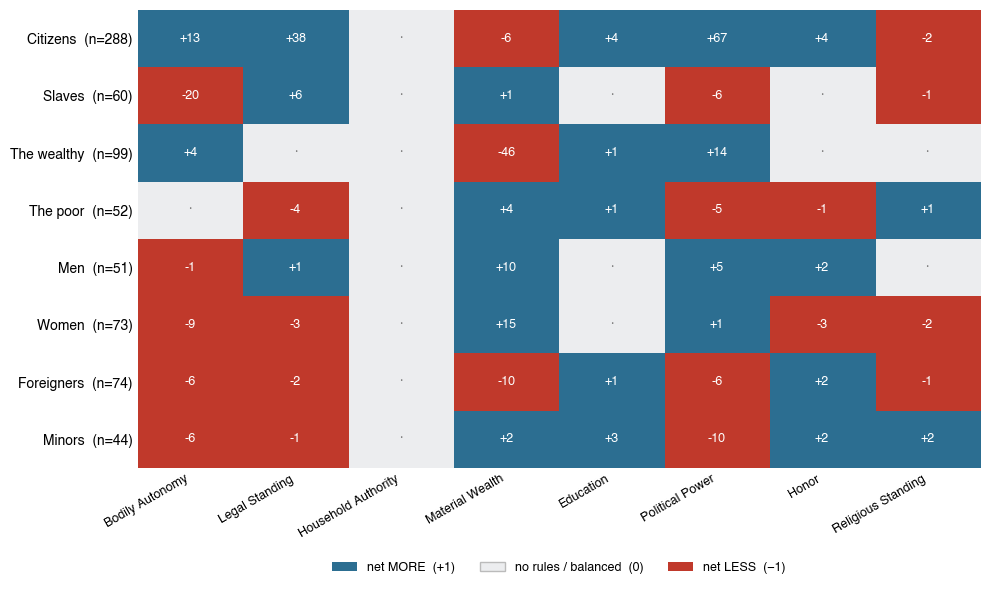

In [16]:
fig, ax = plt.subplots(figsize=(10, 0.55 * len(sign_all) + 1.6))
mat = sign_all.values

# Discrete colormap: -1, 0, +1 → red, grey, blue
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap([NEG_COLOR, ZERO_COLOR, POS_COLOR])
norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

ax.imshow(mat, cmap=cmap, norm=norm, aspect='auto')
ax.set_xticks(range(len(sign_all.columns)))
ax.set_xticklabels(sign_all.columns, rotation=30, ha='right',
                   fontsize=9)
ax.set_yticks(range(len(sign_all.index)))
ax.set_yticklabels([f'{g}  (n={n_all[g]})' for g in sign_all.index],
                   fontsize=10)
ax.tick_params(axis='x', labelbottom=True, length=0)
ax.tick_params(axis='y', labelleft=True, length=0)

# Cell text: net value.
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = net_all.iloc[i, j]
        color = 'white' if mat[i, j] != 0 else '#777'
        ax.text(j, i, f'{v:+d}' if v != 0 else '·',
                ha='center', va='center', fontsize=9, color=color)

handles = [
    mpatches.Patch(facecolor=POS_COLOR, label='net MORE  (+1)'),
    mpatches.Patch(facecolor=ZERO_COLOR, label='no rules / balanced  (0)',
                   edgecolor='#bbb'),
    mpatches.Patch(facecolor=NEG_COLOR, label='net LESS  (−1)'),
]
ax.legend(handles=handles, ncol=3, loc='upper center',
          bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 9. Summary table — one-line takeaway per period

A compact wrap-up: how many cover edges, how flat (width), how layered
(height), how many incomparabilities the partial order surfaces.

In [17]:
summary_df.assign(
    description=lambda d: d.apply(
        lambda r: f"{int(r['width'])} mutually incomparable groups, "
                  f"chain of length {int(r['height'])}",
        axis=1)
)[['n_rules', 'n_groups_in_order', 'cover_edges',
   'height', 'width', 'incomparable_pairs', 'description']]

,n_rules,n_groups_in_order,cover_edges,height,width,incomparable_pairs,description
period,,,,,,,
Classical (500–360 BCE),323,7,6,2,4,15,"4 mutually incomparable groups, chain of length 2"
Late Classical (354–165 BCE),431,8,4,3,6,23,"6 mutually incomparable groups, chain of length 3"
Hellenistic & Early Roman (165 BCE – 105 CE),186,7,2,2,6,19,"6 mutually incomparable groups, chain of length 2"
High Roman Empire (135–205 CE),87,5,4,2,3,6,"3 mutually incomparable groups, chain of length 2"
